In [2]:
from schnetpack.md.utils import HDF5Loader
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from schnetpack.md.utils import MDUnits

%load_ext autoreload
%autoreload 2

In [3]:
data = HDF5Loader('md_logs/2022-05-16_mQEuhRFt/simulation_local_dipole_002.hdf5', load_properties=True, skip_initial=0)

Shape: (200000, 1)


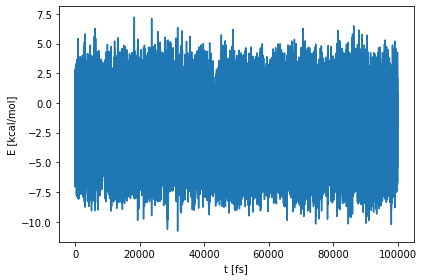

In [4]:
energies = data.get_property('energy')
print('Shape:', energies.shape)

# Get the time axis
time_axis = np.arange(data.entries)*data.time_step / MDUnits.fs2internal # in fs

# Plot the energies
plt.figure()
plt.plot(time_axis, energies)
plt.ylabel('E [kcal/mol]')
plt.xlabel('t [fs]')
plt.tight_layout()
plt.show()

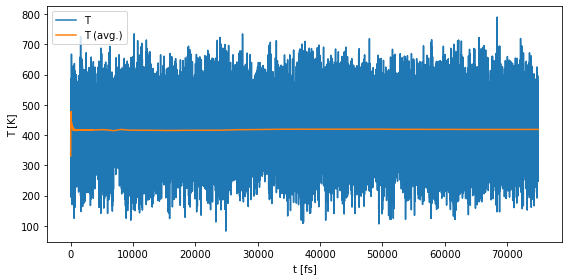

In [10]:
def plot_temperature(data):

    # Read the temperature
    temperature = data.get_temperature()

    # Compute the cumulative mean
    temperature_mean = np.cumsum(temperature) / (np.arange(data.entries)+1)

    # Get the time axis
    time_axis = np.arange(data.entries)*data.time_step / MDUnits.fs2internal # in fs

    plt.figure(figsize=(8,4))
    plt.plot(time_axis, temperature, label='T')
    plt.plot(time_axis, temperature_mean, label='T (avg.)')
    plt.ylabel('T [K]')
    plt.xlabel('t [fs]')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_temperature(data)

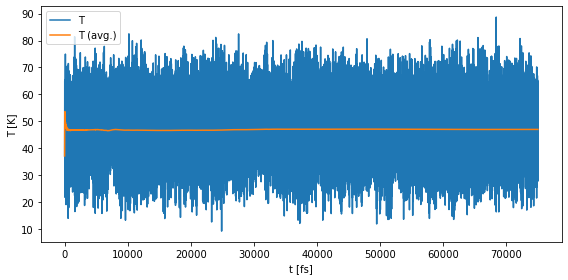

In [11]:
def plot_k_energy(data):

    # Read the k_energy
    k_energy = data.get_kinetic_energy()

    # Compute the cumulative mean
    k_energy_mean = np.cumsum(k_energy) / (np.arange(data.entries)+1)

    # Get the time axis
    time_axis = np.arange(data.entries)*data.time_step / MDUnits.fs2internal # in fs

    plt.figure(figsize=(8,4))
    plt.plot(time_axis, k_energy, label='T')
    plt.plot(time_axis, k_energy_mean, label='T (avg.)')
    plt.ylabel('T [K]')
    plt.xlabel('t [fs]')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_k_energy(data)

std potential 2.4374719
std kinetic 2.420201939298739
energy_unit 0.010364269574711572
kcal 2.5196637345688e+24
kJ 6.022140857000001e+23
ha 2625.4996387552483


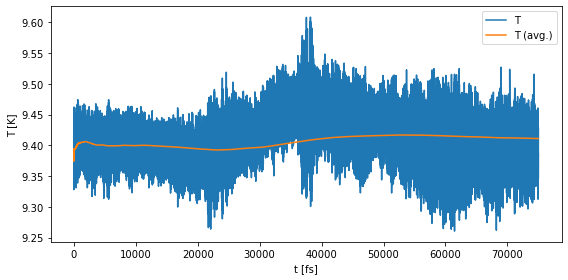

In [12]:
def plot_total_energy(data):

    # Read the k_energy
    k_energy = data.get_kinetic_energy() *  MDUnits.conversions['kj']/MDUnits.conversions['kcal']
    p_energy = data.get_property('energy').squeeze()
    print('std potential', np.std(p_energy))
    print('std kinetic', np.std(k_energy))
    print('energy_unit', MDUnits.energy_unit)
    print('kcal', MDUnits.conversions['kcal'])
    print('kJ', MDUnits.conversions['kj'])
    print('ha', MDUnits.conversions['ha'])
    total_energy = k_energy + p_energy

    # Compute the cumulative mean
    total_energy_mean = np.cumsum(total_energy) / (np.arange(data.entries)+1)

    # Get the time axis
    time_axis = np.arange(data.entries)*data.time_step / MDUnits.fs2internal # in fs

    plt.figure(figsize=(8,4))
    plt.plot(time_axis, total_energy, label='T')
    plt.plot(time_axis, total_energy_mean, label='T (avg.)')
    plt.ylabel('T [K]')
    plt.xlabel('t [fs]')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_total_energy(data)

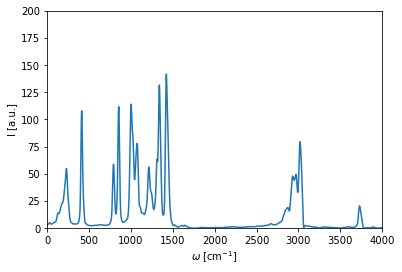

In [13]:
from schnetpack.md.utils.spectra import PowerSpectrum

spectrum = PowerSpectrum(data, resolution=4096)

spectrum.compute_spectrum(molecule_idx=0)
freqencies, intensities = spectrum.get_spectrum()

# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities)
plt.xlim(0,4000)
plt.ylim(0,200)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
plt.show()



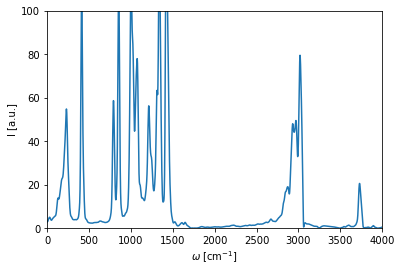

In [14]:
from schnetpack.md.utils.spectra import PowerSpectrum

spectrum = PowerSpectrum(data, resolution=4096)

spectrum.compute_spectrum(molecule_idx=0)
freqencies, intensities = spectrum.get_spectrum()

# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities)
plt.xlim(0,4000)
plt.ylim(0,100)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
plt.show()



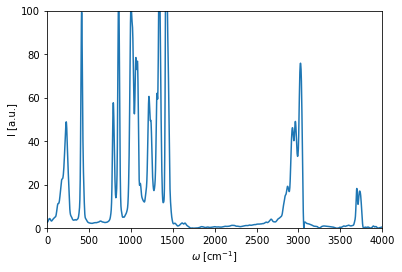

In [14]:
from schnetpack.md.utils.spectra import PowerSpectrum

spectrum = PowerSpectrum(data, resolution=4096)

spectrum.compute_spectrum(molecule_idx=0)
freqencies, intensities = spectrum.get_spectrum()

# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities)
plt.xlim(0,4000)
plt.ylim(0,100)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')


#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/figures/ml_ethanol_vib_spectrum.svg')
plt.show()

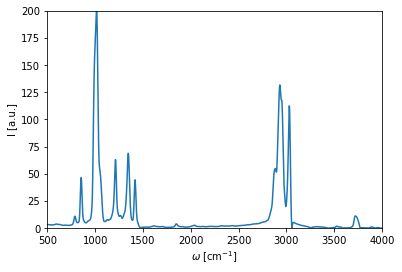

In [10]:
from schnetpack.md.utils.spectra import IRSpectrum

spectrum = IRSpectrum(data, dipole_moment_handle='dipole_moment', resolution=4096)

spectrum.compute_spectrum(molecule_idx=0)
frequencies, intensities = spectrum.get_spectrum()

# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities)
plt.xlim(500,4000)
plt.ylim(0,200)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/figures/ml_ethanol_IR_spectrum.svg')
plt.show()

[0.0000e+00 2.0000e+00 4.0000e+00 ... 3.3350e+04 3.3352e+04 3.3354e+04]


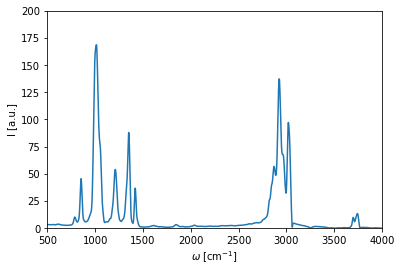

In [39]:
from schnetpack.md.utils.spectra import IRSpectrum
spectrum = IRSpectrum(data, dipole_moment_handle='dipole_moment', resolution=4096)

spectrum.compute_spectrum(molecule_idx=0)
frequencies, intensities = spectrum.get_spectrum()
# Plot the spectrum
print(np.round(frequencies))
plt.figure()
plt.plot(frequencies, intensities)
plt.xlim(500,4000)
plt.ylim(0,200)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/nat_manuscript/figures/ml_ethanol_IR_spectrum.svg')
plt.show()


{'title': 'ETHANOL', 'jcamp-dx': 4.24, 'data type': 'INFRARED SPECTRUM', 'class': 'COBLENTZ', 'origin': 'DOW CHEMICAL COMPANY', 'owner': 'COBLENTZ SOCIETY', 'date': 1964, 'cas registry no': '64-17-5', 'molform': 'C2 H6 O', 'source reference': 'COBLENTZ NO. 8789', '$nist source': 'COBLENTZ', '$nist image': 'cob-r8789', 'spectrometer/data system': 'DOW KBr FOREPRISM-GRATING', 'instrument parameters': 'GRATING CHANGED AT 5.0, 7.5, 15.0 MICRON', 'state': 'GAS (30 mmHg, N2 ADDED, TOTAL PRESSURE 600 mmHg)', 'path length': '5 CM', 'sampling procedure': 'TRANSMISSION', 'resolution': 2, 'data processing': 'DIGITIZED BY NIST FROM HARD COPY (FROM TWO SEGMENTS)', 'xunits': '1/CM', 'yunits': 'TRANSMITTANCE', 'xfactor': 1.0, 'yfactor': 1, 'deltax': 0.9375, 'firstx': 461.563, 'lastx': 3807.5, 'firsty': 0.966, 'maxx': 3807.5, 'minx': 461.563, 'maxy': 1.024, 'miny': 0.142008, 'npoints': 3570, 'xydata': '(X++(Y..Y))', 'end': '', 'x': array([ 461.563    ,  462.7348755,  463.906751 , ..., 3805.625871 ,
  

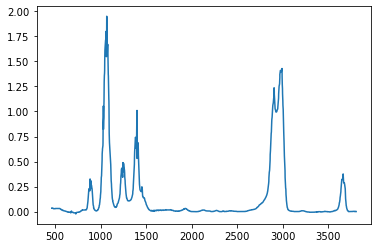

In [8]:
import jcamp

jcamp_data = jcamp.JCAMP_reader('datasets/ethanol_IR.jdx')
print(jcamp_data)
x = np.round(jcamp_data['x'])
y = jcamp_data['y']
y = - np.log(y)
plt.plot(x, y)
plt.show()

In [11]:
freqs = np.round(frequencies)
f_count = 0
f_match = []
x_count = 0
x_match = []

while f_count < len(freqs) and x_count < len(x):
    if freqs[f_count] == x[x_count]:
        f_match.append(f_count)
        x_match.append(x_count)
        f_count += 1
        x_count += 1
    elif freqs[f_count] < x[x_count]:
        f_count += 1
    else:
        x_count += 1

print(len(f_match))
print(len(x_match))
print(freqs[f_match])
print(x[x_match])

1404
1404
[ 462.  464.  466. ... 3803. 3805. 3807.]
[ 462.  464.  466. ... 3803. 3805. 3807.]


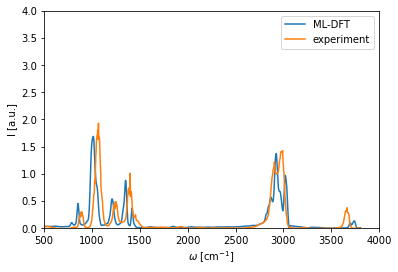

In [69]:
plt.figure()
#plt.plot(freqs[f_match]*0.95 + 100, intensities[f_match]/100)
plt.plot(freqs[f_match], intensities[f_match]/100, label='ML-DFT')
plt.plot(x[x_match], y[x_match], label='experiment')
plt.xlim(500, 4000)
plt.ylim(0,4)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
plt.legend()
plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/nat_manuscript/figures/ml_ethanol_IR_spectrum_comp.pdf')
plt.show()

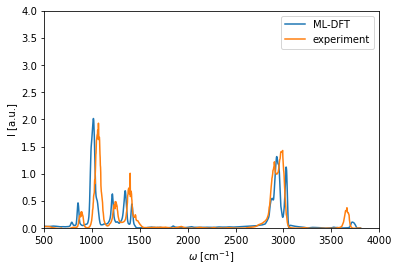

In [12]:
plt.figure()
#plt.plot(freqs[f_match]*0.95 + 100, intensities[f_match]/100)
plt.plot(freqs[f_match], intensities[f_match]/100, label='ML-DFT')
plt.plot(x[x_match], y[x_match], label='experiment')
plt.xlim(500, 4000)
plt.ylim(0,4)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
plt.legend()
#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/nat_manuscript/figures/ml_ethanol_IR_spectrum_comp.pdf')
plt.show()

In [18]:
from schnetpack.md.utils.spectra import fft_autocorrelation
dpm = data.get_property('dipole_moment')
print(dpm.shape)
autocorr = np.zeros((3, dpm.shape[0] - 1))
for i in range(dpm.shape[1]):
    print('i', i)
    autocorr[i] = fft_autocorrelation(dpm[:, i], dpm.shape[0] - 2)

print(autocorr.shape)

(200000, 3)
i 0
i 1
i 2
(3, 199999)


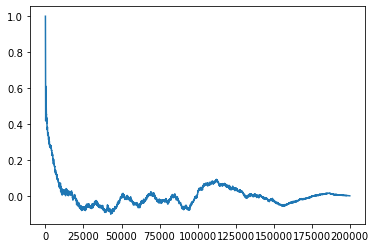

In [19]:
import matplotlib.pyplot as plt

plt.plot(np.mean(autocorr, axis=0))

#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/figures/autocorrelation.svg')
plt.show()

[[ -7.648527    8.224964    6.5621133]
 [-11.796831   12.331962    6.8140025]
 [-13.459861    7.822513   10.413288 ]
 ...
 [ -3.651142    0.9157657 -17.133713 ]
 [ -3.781229   -4.9688816  -6.9968696]
 [ -0.7128417   1.5041827 -10.929107 ]]
i 0
i 1
i 2
(3, 199998)


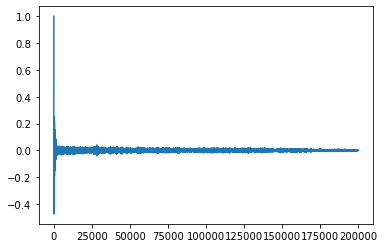

In [20]:
h = 0.5 / 1000

diff = np.diff(dpm, axis=0)
diff = diff/h
print(diff)

autocorr = np.zeros((3, diff.shape[0] - 1))
for i in range(diff.shape[1]):
    print('i', i)
    autocorr[i] = fft_autocorrelation(diff[:, i], diff.shape[0] - 2)
    
print(autocorr.shape)
plt.plot(np.mean(autocorr, axis=0))

#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/figures/diff_autocorrelation.svg')
plt.show()